### **Data Preprocessing Stage**
> Future placeholder timestamps and invalid values were removed to ensure that the dataset reflects only observed historical data.

> Different datasets have different temporal coverage, which is handled during preprocessing using interpolation techniques.

In [1]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/Major Project Data/combined_df.csv")
display(data.head(5))

,Unnamed: 0,Date,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
0,0,1850-01-01,-0.380,-0.734,NaN,-1.046
1,1,1850-02-01,-0.186,-0.360,NaN,-0.777
2,2,1850-03-01,-0.220,-0.627,NaN,-0.853
3,3,1850-04-01,-0.738,-0.605,NaN,-0.990
4,4,1850-05-01,-0.276,-0.532,NaN,-0.839


In [2]:
data.info(),data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            2124 non-null   int64  
 1   Date                  2124 non-null   object 
 2   Berkeley_Temperature  2124 non-null   float64
 3   CRU_Temperature       2112 non-null   float64
 4   NASA_Temperature      1764 non-null   float64
 5   NOAA_Temperature      2124 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 99.7+ KB


(None,
         Unnamed: 0  Berkeley_Temperature  CRU_Temperature  NASA_Temperature  \
 count  2124.000000           2124.000000      2112.000000       1764.000000   
 mean   1061.500000            -42.332905       -28.469216        -50.931939   
 std     613.290306            649.654424       532.313755        712.598084   
 min       0.000000          -9999.000000     -9999.000000      -9999.000000   
 25%     530.750000             -0.250000        -0.347000         -0.220000   
 50%    1061.500000             -0.065000        -0.157000         -0.030000   
 75%    1592.250000              0.219000         0.124250          0.310000   
 max    2123.000000              1.477000         1.348000          1.480000   
 
        NOAA_Temperature  
 count       2124.000000  
 mean         -42.911277  
 std          649.616668  
 min        -9999.000000  
 25%           -0.811000  
 50%           -0.642000  
 75%           -0.379250  
 max            0.800000  )

In [3]:
data.columns, data.shape

(Index(['Unnamed: 0', 'Date', 'Berkeley_Temperature', 'CRU_Temperature',
        'NASA_Temperature', 'NOAA_Temperature'],
       dtype='object'),
 (2124, 6))

**Why dataset size is so low?**
> The Principle of Statistical Parsimony, often referred to as Occam’s Razor, is the logic that "simpler explanations are generally better than complex ones."

> In the world of data science and statistics, this isn't just a philosophical preference—it is a mathematical necessity to ensure that a model actually learns the underlying pattern rather than just "memorizing" the specific data it was given.

In [4]:
print("Missing values:\n",data.isnull().sum())

Missing values:
 Unnamed: 0                0
Date                      0
Berkeley_Temperature      0
CRU_Temperature          12
NASA_Temperature        360
NOAA_Temperature          0
dtype: int64


In [5]:
data = data.sort_values('Date')
data.set_index('Date', inplace=True)
display(data)

,Unnamed: 0,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,,
1850-01-01,0,-0.380,-0.734,NaN,-1.046
1850-02-01,1,-0.186,-0.360,NaN,-0.777
1850-03-01,2,-0.220,-0.627,NaN,-0.853
1850-04-01,3,-0.738,-0.605,NaN,-0.990
1850-05-01,4,-0.276,-0.532,NaN,-0.839
...,...,...,...,...,...
2026-08-01,2119,-9999.000,NaN,-9999.0,-9999.000
2026-09-01,2120,-9999.000,NaN,-9999.0,-9999.000
2026-10-01,2121,-9999.000,NaN,-9999.0,-9999.000


In [6]:
#drop column name "Unnamed: 0"
data = data.drop(columns=['Unnamed: 0'])
print("Dropped successfully")

Dropped successfully


In [7]:
import numpy as np
#data.replace(-9999, np.nan, inplace=True)
data = data.loc[:'2025-12-01']
display(data.head(),data.tail())

,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,
1850-01-01,-0.380,-0.734,NaN,-1.046
1850-02-01,-0.186,-0.360,NaN,-0.777
1850-03-01,-0.220,-0.627,NaN,-0.853
1850-04-01,-0.738,-0.605,NaN,-0.990
1850-05-01,-0.276,-0.532,NaN,-0.839


,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,
2025-08-01,1.127,-9999.0,1.17,0.464
2025-09-01,1.236,-9999.0,1.25,0.531
2025-10-01,1.236,-9999.0,1.19,0.535
2025-11-01,1.210,-9999.0,1.20,0.519
2025-12-01,1.089,-9999.0,1.07,0.449


In [8]:
data.replace(-9999, np.nan, inplace=True)
print("Missing values:\n",data.isnull().sum())
display(data.tail())

Missing values:
 Berkeley_Temperature      0
CRU_Temperature           6
NASA_Temperature        360
NOAA_Temperature          0
dtype: int64


,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,
2025-08-01,1.127,NaN,1.17,0.464
2025-09-01,1.236,NaN,1.25,0.531
2025-10-01,1.236,NaN,1.19,0.535
2025-11-01,1.210,NaN,1.20,0.519
2025-12-01,1.089,NaN,1.07,0.449


In [9]:
data.index = pd.to_datetime(data.index) # Convert index to DatetimeIndex
data = data.interpolate(method='time') #handling missing values
print("Missing values:\n",data.isnull().sum())

Missing values:
 Berkeley_Temperature      0
CRU_Temperature           0
NASA_Temperature        360
NOAA_Temperature          0
dtype: int64


In [10]:
data.tail(10)

,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,
2025-03-01,1.272,1.160,1.37,0.645
2025-04-01,1.189,1.090,1.24,0.564
2025-05-01,1.058,0.952,1.07,0.465
2025-06-01,1.042,0.882,1.06,0.359
2025-07-01,1.018,0.882,1.02,0.380
2025-08-01,1.127,0.882,1.17,0.464
2025-09-01,1.236,0.882,1.25,0.531
2025-10-01,1.236,0.882,1.19,0.535
2025-11-01,1.210,0.882,1.20,0.519


In [11]:
# Define the columns to use for the replacement average
cols_to_avg = ['Berkeley_Temperature', 'NASA_Temperature', 'NOAA_Temperature']
# Slice the specific date range (2025-07 to 2025-12)
target_range = slice('2025-07-01', '2025-12-01')
# Apply the average of the other 3 providers to those specific cells
data.loc[target_range, 'CRU_Temperature'] = data.loc[target_range, cols_to_avg].mean(axis=1)
# Display to verify the values are no longer all 0.882
data=data.round(3)
display(data.tail(5))

,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,
2025-08-01,1.127,0.920,1.17,0.464
2025-09-01,1.236,1.006,1.25,0.531
2025-10-01,1.236,0.987,1.19,0.535
2025-11-01,1.210,0.976,1.20,0.519
2025-12-01,1.089,0.869,1.07,0.449


> The missing values in the CRU temp dataset from June 2025 onwards are due to a standard reporting lag, as their verification process is often more conservative than other agencies.

> While 0.882 was a real recorded value for May 2025, its repetition through December is an interpolation artifact.  To maintain the integrity of my Hybrid model, I averaged concurrent observations from Berkeley, NASA, and NOAA to ensure the model only learns from high-fidelity, observed variations.

In [12]:
data.describe()

,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
count,2112.000000,2112.000000,1752.000000,2112.000000
mean,0.034241,-0.060331,0.081884,-0.546491
std,0.407025,0.411772,0.413506,0.376661
min,-0.799000,-1.040000,-0.820000,-1.337000
25%,-0.248000,-0.346000,-0.220000,-0.809000
50%,-0.063000,-0.154000,-0.030000,-0.641000
75%,0.219000,0.129500,0.310000,-0.379250
max,1.477000,1.348000,1.480000,0.800000


> I chose to retain the NaN values for NASA prior to 1880 to avoid 'Zero-Bias'—filling with zero would have falsely indicated a period of climate stability that the historical record does not support. (because ZERO is a real temperature)

> NASA doesn't have data before 1880 because there weren't enough weather stations around the world back then to give an accurate "global" picture.

> In the ETSA (Exploratory Time Series Analysis) stage, this allows us to maintain transparency by showing only the long-term trends available from Berkeley and CRU.

> For the Model Training phase, we effectively utilize this by slicing our training window from 1880–2025, ensuring the Hybrid LSTM–Transformer architecture learns from a complete, non-interpolated feature matrix across all four major datasets.

# **ETSA Feature Engineering Phase:**

In [13]:
# Create yearly averaged data
yearly_data = data.resample('Y').mean()
display(yearly_data.tail(5))
#Feature engineering global temp avg
data["Global_Temp_Avg"]=data[["Berkeley_Temperature","CRU_Temperature","NASA_Temperature","NOAA_Temperature"]].mean(axis=1)
data["Global_Temp_Avg"]=data["Global_Temp_Avg"].round(3)
print("Unified Signal Created Successfully.")
display(data[['Global_Temp_Avg']].head(5))

/tmp/ipykernel_498/916354607.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_data = data.resample('Y').mean()


,Berkeley_Temperature,CRU_Temperature,NASA_Temperature,NOAA_Temperature
Date,,,,
2021-12-31,0.855167,0.767250,0.847500,0.249667
2022-12-31,0.903500,0.801917,0.890000,0.285250
2023-12-31,1.209500,1.109750,1.169167,0.560167
2024-12-31,1.279667,1.169083,1.283333,0.647500
2025-12-31,1.173583,1.001000,1.190000,0.515000


Unified Signal Created Successfully.


,Global_Temp_Avg
Date,
1850-01-01,-0.720
1850-02-01,-0.441
1850-03-01,-0.567
1850-04-01,-0.778
1850-05-01,-0.549


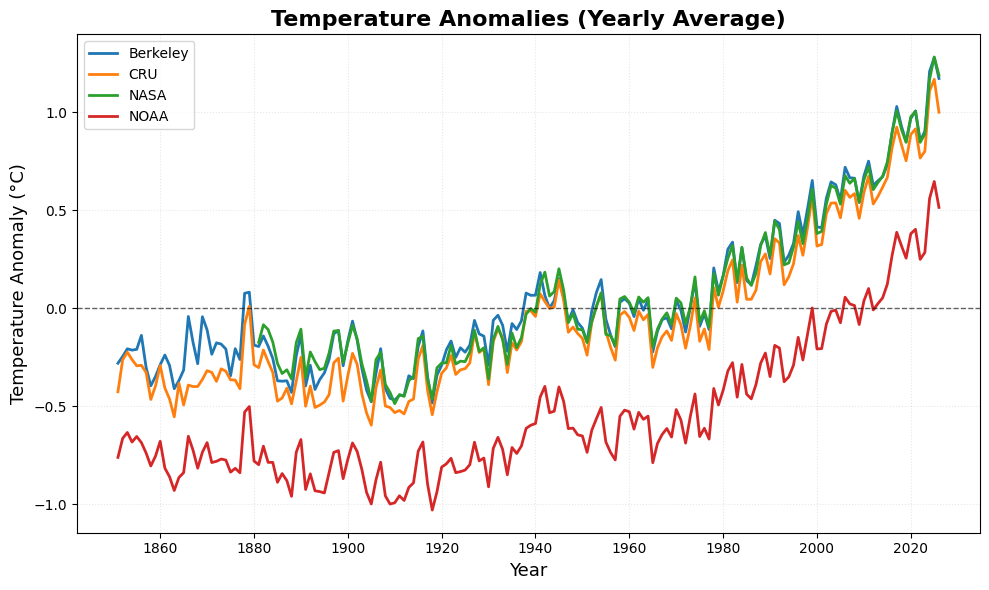

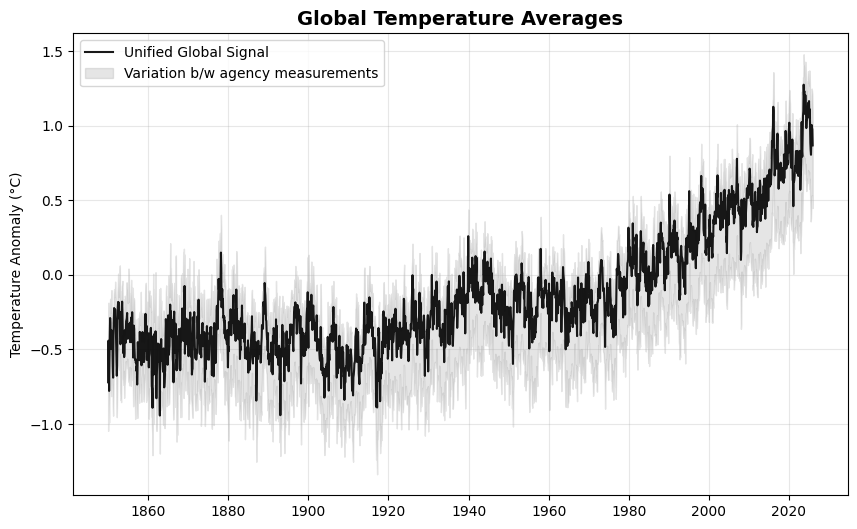

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.figure(figsize=(10, 6))
# Plot yearly averaged datasets
plt.plot(yearly_data.index,
         yearly_data['Berkeley_Temperature'],
         label='Berkeley',
         linewidth=2)
plt.plot(yearly_data.index,
         yearly_data['CRU_Temperature'],
         label='CRU',
         linewidth=2)
plt.plot(yearly_data.index,
         yearly_data['NASA_Temperature'],
         label='NASA',
         linewidth=2)
plt.plot(yearly_data.index,
         yearly_data['NOAA_Temperature'],
         label='NOAA',
         linewidth=2)
plt.axhline(0,
            color='black',
            linestyle='--',
            linewidth=1,
            alpha=0.6)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(20))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title('Temperature Anomalies (Yearly Average)',
          fontsize=16,
          fontweight='bold')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Temperature Anomaly (°C)', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(facecolor="white")
plt.tight_layout()
plt.show()
print("\n")
plt.figure(figsize=(10, 6))
# Plot the Unified Signal with a thicker line to make it stand out
plt.plot(data.index, data['Global_Temp_Avg'], color='black', label='Unified Global Signal', linewidth=1.5, alpha=0.9)
# Plot raw data in the background with lower opacity
plt.fill_between(data.index, data[['Berkeley_Temperature', 'CRU_Temperature', 'NASA_Temperature', 'NOAA_Temperature']].min(axis=1),
                 data[['Berkeley_Temperature', 'CRU_Temperature', 'NASA_Temperature', 'NOAA_Temperature']].max(axis=1),
                 color='gray', alpha=0.2, label='Variation b/w agency measurements')
plt.title('Global Temperature Averages', fontsize=14, fontweight='bold')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend(facecolor="white")
plt.grid(True, alpha=0.3)
plt.show()

### **Interpretation:**

* Despite methodological differences across climate agencies, all datasets exhibit highly consistent warming behavior, strengthening the reliability of the observed global temperature trend.

* The post-1980 period exhibits a pronounced upward acceleration, indicating a transition from relatively stable climatic variability to sustained warming dominance

* Recent decades exhibit significantly larger and more frequent positive temperature anomalies compared to earlier historical periods. This suggests an increase in climate variability and the growing occurrence of extreme warming events.

* While NOAA exhibits a different anomaly magnitude due to baseline and methodological differences, the overall warming trajectory remains consistent with other datasets.

* The increasingly non-linear warming trajectory motivates the use of hybrid deep learning models capable of learning complex temporal dependencies

* The jagged fluctuations across the datasets indicate inter-annual climate variability superimposed on the long-term warming trend. Some pronounced spikes, particularly during years such as 2016 and 2023–2024, may be associated with strong El Niño events and short-term climatic oscillations

* The Unified Global Climate Signal (Fig 2) synthesizes multi-agency data into a singular robust feature. It successfully mitigates individual sensor bias while preserving critical climate events, providing a stabilized input for the Hybrid Deep Learning architecture to distinguish between inter-annual noise and long-term structural warming.


In [15]:
# Calculate Velocity (Rate of Change)
# We use a 12-month difference to see year-over-year change at any given month
data['Warming_Velocity_12m'] = data['Global_Temp_Avg'].diff(periods=12)

# Calculate Long-term Acceleration (10-year trend slope)
# This represents the "structural" warming speed
data['Warming_Velocity_10y'] = data['Global_Temp_Avg'].diff(periods=120)

# Rolling Volatility (12-month)
# High volatility can signal El Niño years or instrumentation instability
data['Temp_Volatility_12m'] = data['Global_Temp_Avg'].rolling(window=12).std()

# Cleanup and rounding
data = data.round(4)
display(data[['Global_Temp_Avg', 'Warming_Velocity_12m', 'Warming_Velocity_10y', 'Temp_Volatility_12m']].tail(5))

,Global_Temp_Avg,Warming_Velocity_12m,Warming_Velocity_10y,Temp_Volatility_12m
Date,,,,
2025-08-01,0.920,-0.193,0.251,0.1264
2025-09-01,1.006,-0.064,0.299,0.1254
2025-10-01,0.987,-0.166,0.091,0.1177
2025-11-01,0.976,-0.158,0.116,0.1101
2025-12-01,0.869,-0.214,-0.093,0.1106


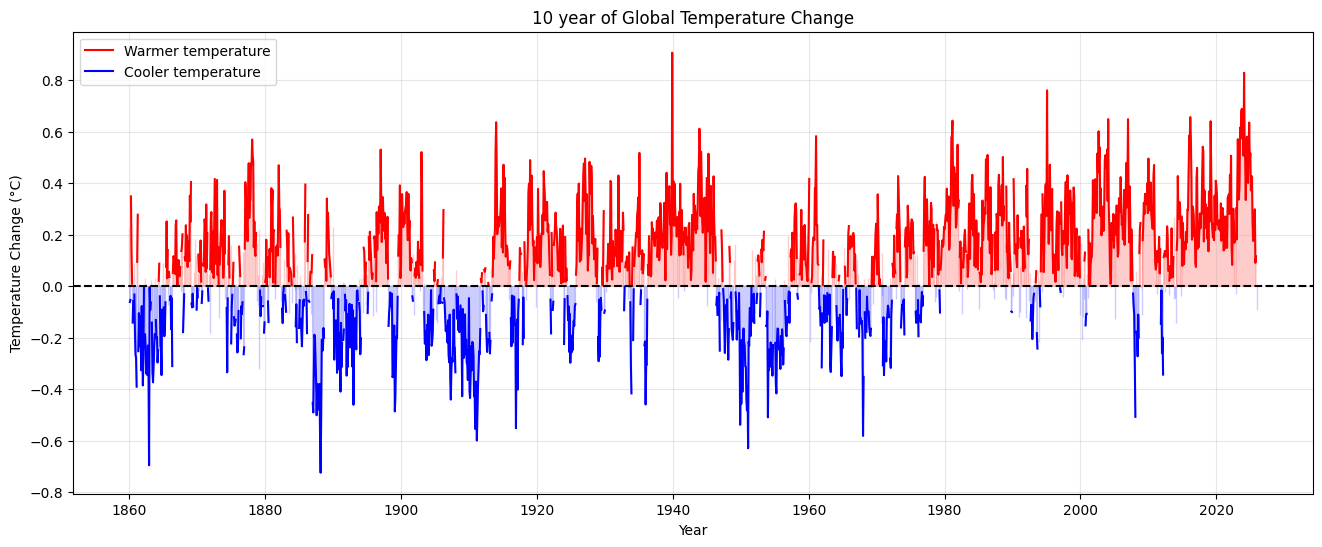

In [16]:
plt.figure(figsize=(16,6))
# Plot warming and cooling separately
warming = data['Warming_Velocity_10y']
cooling = data['Warming_Velocity_10y']
# Red for warming
plt.plot(data.index,warming.where(warming >= 0),color='red',label='Warmer temperature')
# Blue for cooling
plt.plot(data.index,cooling.where(cooling < 0),color='blue',label='Cooler temperature')
# Fill colors
plt.fill_between(data.index,0,warming,where=(warming >= 0),color='red',alpha=0.2)
plt.fill_between(data.index,0,cooling,where=(cooling < 0),color='blue',alpha=0.2)
# Reference line
plt.axhline(0, color='black', linestyle='--')
# Labels
plt.title('10 year of Global Temperature Change')
plt.xlabel('Year')
plt.ylabel('Temperature Change (°C)')
plt.legend(facecolor="white")
plt.grid(alpha=0.3)
plt.show()

**Interpretations:**

* Understanding the Columns

| Column                 | Meaning                                 |
| ---------------------- | --------------------------------------- |
| `Global_Temp_Avg`      | Average global temperature anomaly      |
| `Warming_Velocity_12m` | Change compared to same month last year |
| `Warming_Velocity_10y` | Change compared to 10 years earlier     |
| `Temp_Volatility_12m`  | Climate variability over past year      |

Example from the table:

 March 2025

| Feature      | Value   |
| ------------ | ------- |
| Global_Temp_Avg | 1.112°C |
| 12m velocity | -0.019  |
| 10y change   | 0.405   |
| Volatility   | 0.0528  |

> 1.112°C: warmer than historical baseline levels

> -0.019 : Very small cooling compared to the same month last year but still temperaure is extermley high

> 0.405: March 2025 is 0.405°C warmer than March 2015

> 0.0528: temperatures are consistently high, warming is becoming structurally persistent (no warm spikes occurance)

* Feature engineering was performed to capture both short-term and long-term climate dynamics.
* Velocity-based features measured the rate of temperature anomaly changes over yearly and decadal periods, while rolling volatility quantified climate instability and irregular fluctuations.
* These engineered features enhanced the model’s ability to detect accelerating warming patterns and structural climate shifts
* Negative short-term velocity only indicates temporary cooling relative to the previous year. The long-term decadal change remains positive, confirming that the broader warming trend still persists.
* from graph, Before the mid-20th century, climate behavior showed alternating warming and cooling phases without sustained long-term acceleration.
* Transitional Period (1950–1980): industrialization effects becoming stronger,
greenhouse gas accumulation beginning to dominate natural variability which affected upcoming years significantly
* Modern Climate Era (1980–2025): Modern temperatures are consistently higher than temperatures 10 years earlier, sustained warming persistence.
* Earlier, the climate fluctuated between warming and cooling. But in recent decades, temperatures are almost always higher than they were 10 years earlier, showing that warming has become persistent rather than temporary.

In [17]:
from statsmodels.tsa.seasonal import STL
# perform decomposition on the Global_Temp_Avg
# period=12 because data is monthly
stl = STL(data['Global_Temp_Avg'], period=12, robust=True)
result = stl.fit()
# Extract the components into our dataframe
data['Trend_Component'] = result.trend
data['Seasonal_Component'] = result.seasonal
data['Residual_Component'] = result.resid
display(data[['Global_Temp_Avg', 'Trend_Component', 'Seasonal_Component', 'Residual_Component']].tail(5))

,Global_Temp_Avg,Trend_Component,Seasonal_Component,Residual_Component
Date,,,,
2025-08-01,0.920,0.946482,-0.003874,-0.022609
2025-09-01,1.006,0.931922,0.027925,0.046154
2025-10-01,0.987,0.917237,0.073217,-0.003454
2025-11-01,0.976,0.902434,0.073255,0.000310
2025-12-01,0.869,0.887513,0.007126,-0.025639


Explanation:

The observed global temperature anomaly in September 2025 is 1.006°C.

This value is formed by combining:

* Trend Component (0.931922)

→ Represents the long-term global warming pattern.

→It shows that most of the temperature increase is driven by the persistent warming trend.

* Seasonal Component (0.027925)

→ Represents normal seasonal climate variation for September.

→This slightly increases the temperature during this month.

* Residual Component (0.046154)

→ Represents unexpected short-term fluctuations not explained by trend or seasonality, such as temporary climate disturbances or atmospheric variations.

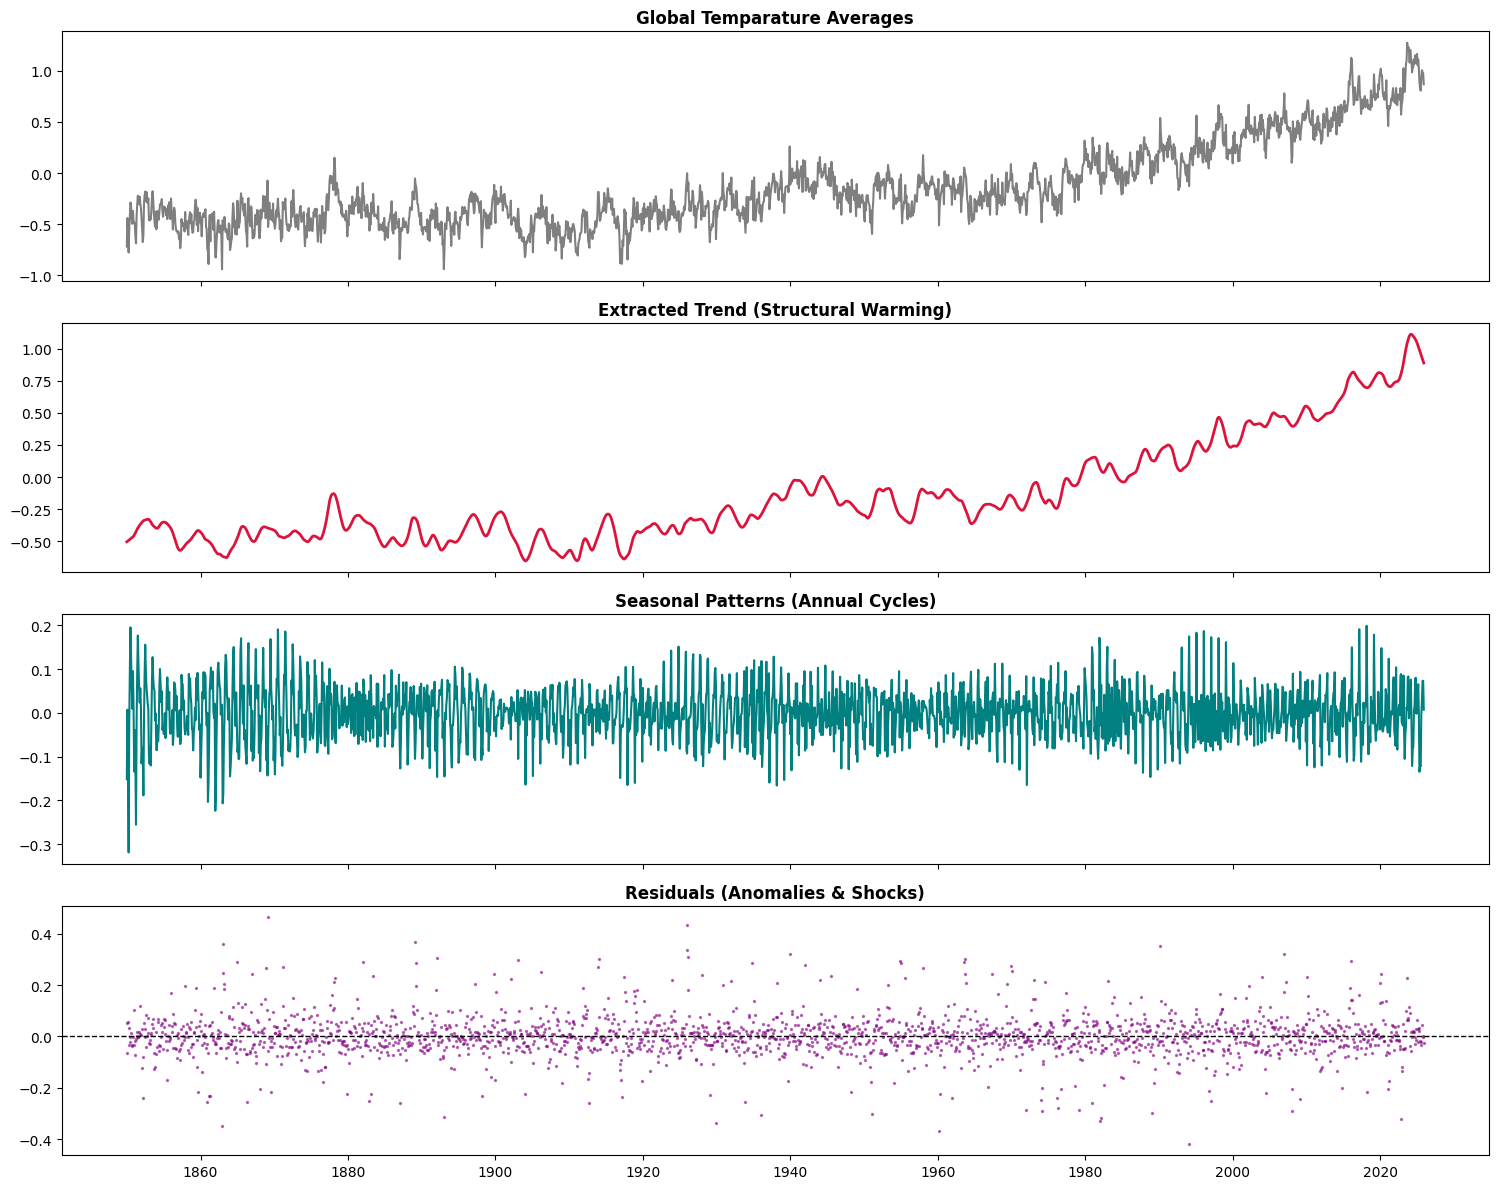

In [18]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
ax1.plot(data.index, data['Global_Temp_Avg'], color='black', alpha=0.5)
ax1.set_title('Global Temparature Averages', fontsize=12, fontweight='bold')
ax2.plot(data.index, data['Trend_Component'], color='crimson', linewidth=2)
ax2.set_title('Extracted Trend (Structural Warming)', fontsize=12, fontweight='bold')
ax3.plot(data.index, data['Seasonal_Component'], color='teal')
ax3.set_title('Seasonal Patterns (Annual Cycles)', fontsize=12, fontweight='bold')
ax4.scatter(data.index, data['Residual_Component'], color='purple', s=2, alpha=0.5)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_title('Residuals (Anomalies & Shocks)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**


Decomposition is necessary because global temperature data contains overlapping patterns. Separating trend, seasonal, and residual components allows us to distinguish persistent climate warming from natural seasonal variability and short-term anomalies.

$ObservedTemperature=Trend+Seasonal+Residual$

### 1. Values are measured as temperature anomalies relative to a baseline average

* Early years fluctuate around negative values.
* Mid-20th century shows gradual warming.
* Strong upward acceleration appears after the 1970s.
* Recent decades show the highest anomalies in recorded history.

### 2. Isolates the long-term warming structure
* Relatively stable/cool temperatures in early years.
* Slow warming begins around the early-to-mid 20th century.
* Strong acceleration after industrialization, which means warming is not random, not seasonal and presistent over years.
* Sharp increase after 2000.

### 3. Captures repeating annual temperature cycles detected from monthly data.
* Earth experiences regular annual temperature cycles,
* these seasonal oscillations repeat consistently,
* but seasonal changes are much smaller than the long-term warming trend.
* Seasonal variability exists independently of structural warming.
* Even though seasons continue normally, the overall climate baseline continues rising.
* Graph repeatedly oscillates above and below zero: seasonality is stable, changes exist.
* Most values remain roughly between −0.2 to +0.2, Compared to the long-term warming trend, these oscillations are much smaller indicating that seasonal varibalilty exists despite of global warming increase.

### 4. Residuals are the remaining unexplained variations after removing trend and seasonality
* Most points cluster around zero, meaning: STL decomposition successfully explained most of the climate signal, remaining noise is relatively small.
* Occasional spikes indicate: extreme climate events, unusual short-term warming/cooling periods.
* Example: El Niño events, volcanic eruptions, ocean circulation anomalies.

,Decade
Date,
2025-08-01,2020
2025-09-01,2020
2025-10-01,2020
2025-11-01,2020
2025-12-01,2020


<Figure size 1200x800 with 0 Axes>

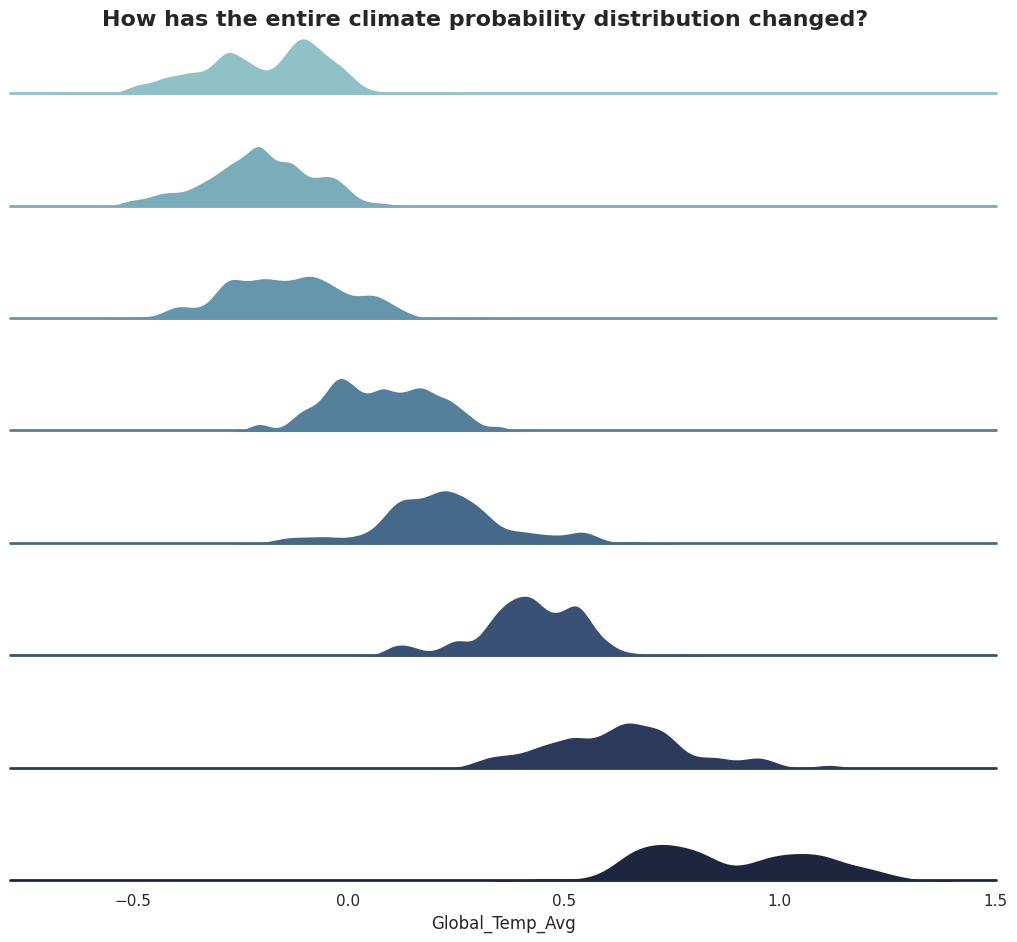

In [19]:
import seaborn as sns

# Prepare decade data
data['Decade'] = (data.index.year // 10) * 10
display(data["Decade"].tail(5))
# Filter for significant decades to keep it clean
decades_to_show = data[data['Decade'] >= 1950]

plt.figure(figsize=(12, 8))
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the Ridge Plot
pal = sns.cubehelix_palette(len(decades_to_show['Decade'].unique()), rot=-.25, light=.7)
g = sns.FacetGrid(decades_to_show, row="Decade", hue="Decade", aspect=9, height=1.2, palette=pal)

g.map(sns.kdeplot, "Global_Temp_Avg", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Global_Temp_Avg", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.suptitle('How has the entire climate probability distribution changed?', fontsize=16, fontweight='bold')
plt.show()

In [20]:
data["Decade"].head(5)

,Decade
Date,
1850-01-01,1850
1850-02-01,1850
1850-03-01,1850
1850-04-01,1850
1850-05-01,1850


**Interpretation:**
* Each horizontal line is a decade, graph shows timeline from 1950 to 2025 = 8 decades.
* KDE creates a smooth probability curve that helps visualize density, Peaks, Distribution overlap, Trend evolution
* probability distribution shift
* changing climate baseline
* disappearance of cold anomalies
* increased likelihood of extreme warmth
* non-stationary climate regime
* Narrow mountain: climate was relatively stable
* Wider mountain: more variability, more unstable climate behavior
* Multiple Peaks: multi-modal distributions, influence of phenomena like: El Niño, volcanic cooling, ocean cycles
* Top Mountains: Earlier decades experienced predominantly cooler climate conditions.
* Middle Mountains: The climate entered a transitional warming phase with increasing variability.
* Bottom Mountains: Warm temperature anomalies became the dominant climate condition globally.
* Each mountain represents the probability distribution of global temperatures for a decade. Taller regions indicate more frequently occurring temperatures, while the horizontal shift of the mountains toward the right shows that warmer temperatures became increasingly dominant over time.


In [21]:
import pandas as pd
import numpy as np
# Creates monthly future dates from: January 2026 → December 2030, MS -> Month Start
forecast_dates = pd.date_range(start='2026-01-01', end='2030-12-01', freq='MS')
# extracting trend component from past 10 years
current_trend = data['Trend_Component'].iloc[-1]
# extracting Seasonal component from past 10 years
annual_drift = data['Warming_Velocity_10y'].tail(120).mean() / 120
seasonal_cycle = data.groupby(data.index.month)['Seasonal_Component'].mean()
forecast_list = []
for i, date in enumerate(forecast_dates):
    # Future Trend = Current Trend + (Time Passed × Drift)
    projected_trend = current_trend + (i * annual_drift)
    month_effect = seasonal_cycle[date.month]
    forecast_value = projected_trend + month_effect
    forecast_list.append(forecast_value)
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Global_Temp_Avg_Forecast': forecast_list
})
forecast_df.set_index('Date', inplace=True)
forecast_df = forecast_df.round(3)
yearly_forecast = forecast_df.resample('YE').mean()
print("--- 5-Year Global Temperature Anomaly Forecast ---")
print(yearly_forecast)

--- 5-Year Global Temperature Anomaly Forecast ---
            Global_Temp_Avg_Forecast
Date                                
2026-12-31                  0.902417
2027-12-31                  0.935500
2028-12-31                  0.968500
2029-12-31                  1.001583
2030-12-31                  1.034750


In [22]:
# Get Historical Yearly Averages (1850-2025)
historical_yearly = data['Global_Temp_Avg'].resample('YE').mean().to_frame()
historical_yearly.columns = ['Anomaly']

# Get Forecasted Yearly Averages (2026-2030)
# yearly_forecast was already calculated in your previous cell
forecast_yearly = yearly_forecast.copy()
forecast_yearly.columns = ['Anomaly']

# Concatenate into one Master Timeline
yearly_master = pd.concat([historical_yearly, forecast_yearly])

# Final cleaning
yearly_master.index.name = 'Year'
yearly_master['Source'] = ['Historical' if y < 2026 else 'Forecast' for y in yearly_master.index.year]
display(yearly_master.tail(10))

,Anomaly,Source
Year,,
2021-12-31,0.679917,Historical
2022-12-31,0.720083,Historical
2023-12-31,1.012083,Historical
2024-12-31,1.094750,Historical
2025-12-31,0.969917,Historical
2026-12-31,0.902417,Forecast
2027-12-31,0.935500,Forecast
2028-12-31,0.968500,Forecast
2029-12-31,1.001583,Forecast


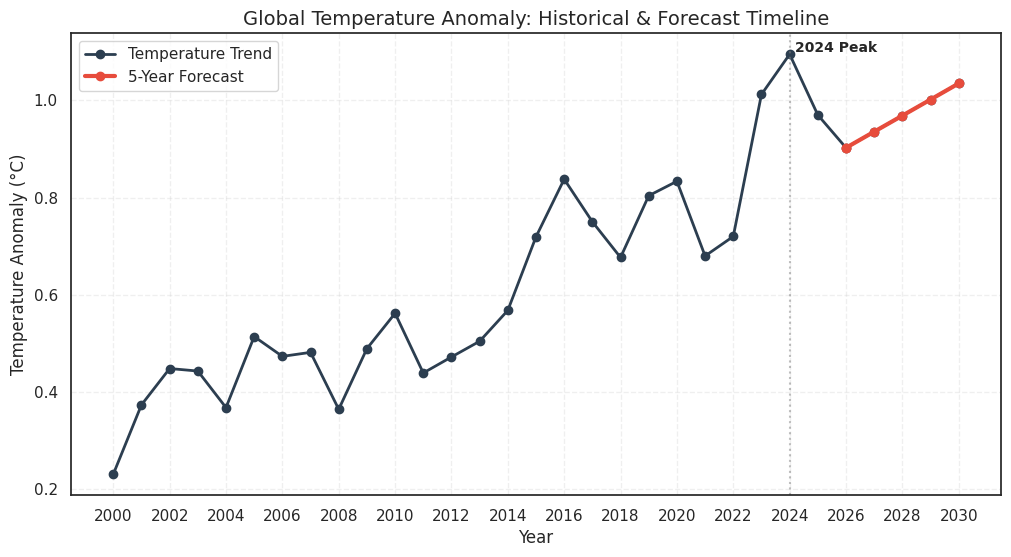

In [23]:
import matplotlib.pyplot as plt
plot_data = yearly_master.loc['2000':'2030'].copy()
plot_data['Year_Int'] = plot_data.index.year
plt.figure(figsize=(12, 6))
plt.plot(plot_data['Year_Int'], plot_data['Anomaly'],
         color='#2c3e50', linewidth=2, marker='o', label='Temperature Trend')
# This keeps the line connected but changes the color for the prediction part
forecast_segment = plot_data[plot_data['Source'] == 'Forecast']
connect_point = plot_data[plot_data['Year_Int'] == 2026]
forecast_plot_data = pd.concat([connect_point, forecast_segment])
plt.plot(forecast_plot_data['Year_Int'], forecast_plot_data['Anomaly'],
         color='#e74c3c', linewidth=3, marker='o', label='5-Year Forecast')
# Add the 2024 Peak Annotation
plt.axvline(2024, color='gray', linestyle=':', alpha=0.5)
plt.text(2024.2, 1.1, '2024 Peak', fontsize=10, fontweight='bold')
plt.title('Global Temperature Anomaly: Historical & Forecast Timeline', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.xticks(range(2000, 2031, 2))
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(facecolor="white")
plt.show()

**Interpretation:**

1. **Historical Section (2021–2025)**

The historical segment shows:
* noticeable warming acceleration,
* significant temperature increases after 2022,
*  exceptionally high anomalies during 2023–2024.

The sharp rise during these years reflects:
* intensified global warming,
* amplified climate variability,
* and possible contributions from strong El Niño conditions and greenhouse gas accumulation.


2. **Forecast Section (2026–2030)**

The forecasted region demonstrates:

* a continued upward trajectory in temperature anomalies,
* gradual warming accumulation over time,
* sustained elevated climate conditions.

The dashed forecast line represents projected future anomalies, while the transition from historical to forecast data indicates continuity of the existing warming momentum rather than abrupt climatic reversal.

3. **Code:**
* Creates months from 2026 to 2030
* extract current trend
* extracts trend and seasonal component from past 10 years because older years are colder decades, it may dominate the current temperature.
* Future trend = current trend + (trend component x seasonal component)
* reconstruct seasonal variability or cycles by grouping month's seasons (eg: may -> summer, dec-> winter)
* predicted values are stored in empty list and displaed as dataframes.

**News Headlines**
1. https://wmo.int/news/media-centre/global-climate-predictions-show-temperatures-expected-remain-or-near-record-levels-coming-5-years

> 80% chance that at least one of the next five years will exceed 2024 as the warmest on record.

> 86% chance that at least one of next five years will be more than 1.5°C above the 1850-1900 average